# 长尾异常值驱动训练
- 是指训练过程中，<font color='red'>分布尾部的极端异常样本因产生过大的梯度或优势信号，反客为主地主导了模型参数更新方向</font>，导致策略偏离正常学习轨道的现象。
- 它与你之前问的"零方差组"恰好构成一组对称问题
  - 零方差组是"<font color='red'>没有信号</font>"
  - 长尾异常值驱动是"<font color='red'>信号太强、太偏</font>"

**具体机制与影响如下：**

## 🔍 核心机制
在强化学习（尤其是 PPO/GRPO）训练过程中，模型对每个 Prompt 采样一组回复并计算奖励，然后通过优势函数（Advantage）来更新策略。
  - 正常情况下，大多数样本的奖励分布在一个合理范围内，梯度信号是平滑且方向一致的。

### 但长尾异常值的出现打破了这一平衡：
  - 极端奖励样本：
    - 极少数回复获得了异常高（或异常低）的奖励，远超批次中其他样本。
      - 比如一个 batch 里 99% 的回复奖励在 0.3~0.7 之间，<font color='red'>但有 1% 的回复因为某种边界情况获得了接近满分或零分的奖励(极端值)</font>。
  - 优势值被极端样本绑架：
    - 优势函数 A_i = (r_i - μ) / (σ + ε) 中，<font color='red'>当存在极端值时，均值 μ 和标准差 σ 都被拉偏</font>，<font color='blue'>导致正常样本的优势值被压缩到接近零，而异常样本的优势值被放大到极大。</font>
  - 梯度方向被少数样本决定：
    - PPO 的策略梯度正比于优势值与策略梯度的乘积。<font color='blue'>当异常样本的优势值远大于正常样本时，参数更新几乎完全由这些异常样本决定</font>，<font color='red'>模型"学到"的是如何复现这些极端行为</font>，而非泛化能力。
    
## 🎯 典型触发场景
 - 奖励函数设计缺陷：
   - 奖励函数存在不连续的跳变。比如二值奖励（对/错）下，某些 Prompt 的正确答案恰好触发了一个意外的奖励峰值（如格式匹配奖励与内容奖励叠加），导致该回复的奖励远高于其他回复。
 - KL 惩罚失效：
   - <font color='blue'>当 KL 系数设置过小</font>，策略可以大幅偏离参考模型，**某些回复可能进入参考模型几乎不给概率的区域(π_old很小)，获得异常高的奖励比率** r(θ) = π_θ / π_old，进而产生爆炸性梯度。
 - 数据中的边界样本：
   - <font color='blue'>训练数据中存在少量极端样本（如超长序列、罕见话题、格式异常的 Prompt），这些样本在 rollout 阶段产生了异常的奖励分布</font>
 - 奖励模型（RM）的不确定性：
   - 在 RLHF 中，奖励模型对**分布外**<font color='blue'>输入的预测可能极不稳定</font>，某些输入恰好落在 RM 的高置信度区域之外，产生不可靠的极端奖励值。
   
## ⚠️ 三大危害
  - 策略偏移：
    - 模型过度拟合少数异常样本的行为模式，丧失对正常样本的泛化能力。
      - 表现为：<font color='blue'>大部分对话质量下降，但在某些特定边界场景下表现异常好。</font>
  - 训练不稳定：
    - 异常样本产生的大梯度导致参数剧烈震荡，loss 曲线出现尖峰，训练难以收敛。
  - 奖励黑客（Reward Hacking）：
    - 模型学会利用奖励函数的漏洞来获取高分，而非真正提升输出质量。
      - <font color='blue'>比如学会生成特定格式来触发格式奖励，但内容质量并未提升。</font>
    
## 🛡️ 主流防御手段
  - 奖励裁剪（Reward Clipping）：
    - 将奖励值限制在合理范围内（如 [-1, 1]），防止极端值影响优势计算。
  - 优势归一化：
    - <font color='blue'>对每个 batch 的优势值进行标准化处理，减少极端值的影响。</font>
  - 梯度裁剪（Gradient Clipping）：
    - 限制单次更新的梯度范数，防止异常样本产生过大的参数更新。
  - KL 散度约束：
    - 增大 KL 系数，限制策略偏离参考模型的程度，防止策略进入异常区域。
  - 异常样本过滤：
    - <font color='blue'>在计算优势之前，检测并剔除奖励分布中的离群点（如超过 3σ 的样本）。</font>
  - 鲁棒优势估计：
    - 使用中位数或截尾均值替代均值来计算优势函数，降低对极端值的敏感度。

## 📌 与零方差组的对比总结
| 维度 | 零方差组 | **长尾异常值驱动** |
|------|----------|----------------|
| 本质 | 信号缺失 | 信号过载 |
| 表现 | 梯度为零，模型不更新 | <font color='blue'>梯度被少数样本绑架，方向偏斜 </font>|
| 成因 | 组内奖励完全一致 | <font color='red'>组内存在极端异常奖励</font> |
| 危害 | 算力浪费，学习停滞 | <font color='red'>策略偏移，训练不稳定</font> |
| 应对 | 注入方差 / 过滤无效组 | 裁剪 / 归一化 / 过滤异常值 |

两者共同构成了 RL 训练中"信号质量"的两端风险
- 太少不行，太多也不行。
- 工程排查时，<font color='red'>建议同时监控组内方差的下界（防零方差）和奖励分布的尾部（防异常值驱动），确保训练信号始终处于健康区间。</font>


# 异常样本过滤：
- <font color='blue'>在计算优势之前，检测并剔除奖励分布中的离群点（如超过 3σ 的样本）。</font>


**这个策略的核心思想是：**
- 在计算优势值之前，<font color='blue'>先对奖励数据进行“清洗”，剔除那些极端异常的离群点</font>，防止它们主导梯度更新，导致模型训练不稳定。

简单来说，就是“**别让几个极端的特例带偏了整个班级的学习方向**”。

## 为什么要这样做？（背景与痛点）
在强化学习（尤其是 PPO 等策略梯度算法）中，<font color='red'>优势函数的计算通常依赖于奖励的分布。</font>
- 问题场景：假设在一个 batch 中，99 个样本的奖励都是 1.0，但有 1 个样本因为某种 Bug 或极端运气获得了 1000.0 的奖励。
- 后果：
  - 均值被拉高：**整个 batch 的平均奖励会被这一个样本拉得很高。**
  - 优势值失真：那 99 个正常样本的优势值会变成负数（因为 1.0−mean < 0 ），<font color='red'>模型会误以为这些正常的行为是“错误的”并加以抑制</font>；
    - <font color='blue'>而那个异常样本会被赋予巨大的正优势，模型会疯狂拟合这个可能是噪声的数据点。</font>
  - 梯度爆炸：巨大的优势值会导致巨大的梯度更新，可能直接破坏已经训练好的参数。
- 解决方案：在计算均值和标准差之前，先把那个 1000.0 的“坏苹果”扔掉。

## “超过 3σ （sigma） ”的具体含义
这里的 σ 指的是**标准差**。

统计学中有一个经验法则（3σ 原则）：
- <font color='blue'>对于正态分布的数据，99.7% 的数据都应该落在均值左右 3 个标准差的范围内。</font>
- 判定逻辑：<font color='red'>如果一个样本的奖励值 $R_i$满足以下条件，就被视为离群点：</font>

$∣R_i − μ∣>3 × σ$
- 其中 μ 是当前 batch 奖励的均值， 
- σ 是标准差。

## 代码实现逻辑
<font color='red'>在实际工程中，直接删除数据可能会导致数组维度变化，处理起来比较麻烦。更常见的做法是“截断”或“置零”，或者在计算统计量时“掩码屏蔽”。</font>

以下是一个标准的实现流程示例：

In [7]:
import numpy as np

def filter_reward_outliers(rewards, threshold_sigma=3.0):
    """
    过滤奖励分布中的离群点
    :param rewards: numpy数组，当前batch的原始奖励
    :param threshold_sigma: 阈值倍数，默认为3倍标准差
    :return: 过滤后的奖励数组（离群点被替换为边界值或NaN以便后续处理）
    """
    mean = np.mean(rewards)
    std = np.std(rewards)
    print(std)

    # 防止标准差为0的情况（所有奖励都一样）
    if std < 1e-8:
        return rewards

    # 计算上下界
    lower_bound = mean - threshold_sigma * std
    print(lower_bound)
    upper_bound = mean + threshold_sigma * std
    print(upper_bound)

    # --- 策略 A：截断法 (Clipping) —— 推荐，最稳健 ---
    # 将超过边界的值强行拉回到边界上，保留样本数量不变
    filtered_rewards = np.clip(rewards, lower_bound, upper_bound)

    # --- 策略 B：掩码法 (Masking) —— 用于计算优势时完全忽略 ---
    # mask = (rewards >= lower_bound) & (rewards <= upper_bound)
    # 如果要用这个方法，后续计算均值方差时只传 rewards[mask]

    return filtered_rewards


# 原始奖励: [ 1.   1.2  0.9  1.1 50. ]
# 清洗后:   [ 1.   1.2  0.9  1.1 50. ]
# 50.0 < 69.22，所以 50.0 不会被截断，过滤完全失效。

In [8]:
# 模拟使用场景
raw_rewards = np.array([1.0, 1.2, 0.9, 1.1, 50.0]) # 50.0 是明显的离群点
clean_rewards = filter_reward_outliers(raw_rewards)

print(f"原始奖励: {raw_rewards}")
print(f"清洗后:   {clean_rewards}")

19.580255360949714
-47.900766082849145
69.58076608284914
原始奖励: [ 1.   1.2  0.9  1.1 50. ]
清洗后:   [ 1.   1.2  0.9  1.1 50. ]


### 修复方案：用鲁棒统计量替代均值和标准差
- 将 mean 和 std 替换为**中位数**和**MAD**（中位数绝对偏差），它们不受极端值影响：

In [9]:
def filter_reward_outliers(rewards, threshold_sigma=3.0):
    median = np.median(rewards)
    # MAD 是标准差的鲁棒替代，乘以 1.4826 使其在正态分布下与标准差一致
    mad = np.median(np.abs(rewards - median)) * 1.4826

    if mad < 1e-8:
        return rewards

    lower_bound = median - threshold_sigma * mad
    upper_bound = median + threshold_sigma * mad

    filtered_rewards = np.clip(rewards, lower_bound, upper_bound)
    return filtered_rewards

In [10]:
# 模拟使用场景
raw_rewards = np.array([1.0, 1.2, 0.9, 1.1, 50.0]) # 50.0 是明显的离群点
clean_rewards = filter_reward_outliers(raw_rewards)

print(f"原始奖励: {raw_rewards}")
print(f"清洗后:   {clean_rewards}")

原始奖励: [ 1.   1.2  0.9  1.1 50. ]
清洗后:   [1.      1.2     0.9     1.1     1.54478]


#### MAD 是标准差的鲁棒替代，乘以 1.4826 使其在正态分布下与标准差一致

##### 什么是 MAD？
MAD（Median Absolute Deviation，**中位数绝对偏差**）<font color='red'>是衡量数据离散程度的统计量，定义为各数据点与中位数之差的绝对值的中位数：</font>
$MAD=median(∣X_i−median(X)∣)$

###### 计算步骤：
  1. 求数据的中位数
  2. 计算每个数据点到中位数的绝对偏差
  3. 取这些绝对偏差的中位数

- 示例：数据 [1, 2, 3, 4, 5]，
  - 中位数为 3，
  - 绝对偏差为 [2, 1, 0, 1, 2]，
  - MAD = median([2,1,0,1,2]) = 1。

###### <font color='red'>为什么 MAD 是标准差的"鲁棒替代"？</font>
**标准差对极端值极其敏感（偏差会被平方放大），而 MAD 天然抗干扰：**

  - 中心估计：用中位数（不受极端值影响）替代均值。
  - 离散度量：用绝对偏差的中位数（只关心排序位置）替代平方偏差的均值。
  - 崩溃点：理论上可抵抗高达 50% 的数据被污染而不失效。

- 对比：数据 [1, 1.1, 0.9, 1.2, 50] 中，
  - 标准差被 50 拉高到约 19.5，
  - 而 MAD 仍稳定在约 0.1。

In [11]:
from IPython.display import Image

###### 为什么乘以 1.4826？（数学推导）

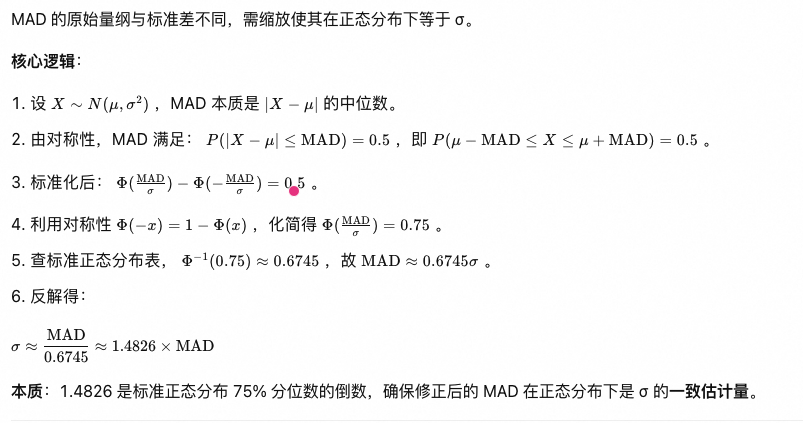

In [12]:
Image(filename='./Image/1.4826.png')

###### 实际意义
乘以 1.4826 后，可直接套用传统 3σ 规则（如 median ± 3 × 1.4826 × MAD），同时享受鲁棒性：
  - 正常数据：结果与标准差法一致。
  - 含离群点：标准差法失效，MAD 法仍能正确识别。
  
###### 局限性
  - 分布假设：1.4826 仅在正态分布下精确；非正态分布下关系不同，但仍可作为鲁棒尺度估计。
  - 崩溃点：异常值占比超过 50% 时失效。
  - 统计效率：在纯正态分布下效率低于标准差（约 37%），但换来的是鲁棒性。

##  这种方法的优缺点分析
### ✅ 优点
  - 提高稳定性：极大地减少了因环境 Bug、物理引擎穿模或极端随机性导致的梯度尖峰。
  - 保护模型：防止模型为了迎合极少数的异常高分而过拟合，或者因为异常低分而崩溃。
  - 实施简单：只需要几行代码，不需要修改网络结构。
### ⚠️ 风险与注意事项
- 可能会误杀“高光时刻”：如果模型真的学会了一个极其厉害的操作（比如在游戏中打出了罕见的高分连招），它的奖励也会远超平均值。如果直接过滤掉，模型就学不到这个高级技巧了。
  - 对策：随着训练进行，模型变强，平均分提高，原本的高分就不再是离群点了。所以这个机制主要在训练初期或环境噪声大时有效。
- 计算依赖：你需要先算出 Mean 和 Std 才能判断谁是离群点。如果离群点太多（比如超过 10%），它们本身就会把 Mean 和 Std 拉偏，导致过滤失效。
  - 对策：可以使用中位数和绝对中位差来代替均值和标准差进行初步判断，但这会增加计算复杂度。通常 RL 中直接用第一遍计算的 Mean/Std 做简单过滤就够了。
  
##  总结
- 这句话的意思是：在把奖励喂给算法去计算“哪个动作更好”之前，<font color='red'>先用统计学方法把那些太离谱的数据（太高或太低）修剪一下</font>，保证大家是在一个正常的范围内比较优劣，**从而让训练过程更平滑、不崩盘**。

# 在强化学习（尤其是 PPO 等策略梯度算法）中，<font color='red'>优势函数的计算通常依赖于奖励的分布</font>

- 优势函数的核心作用是充当<font color='red'>“相对标尺”</font>，通过从实际回报中<font color='red'>减去奖励分布的**均值（基线）**来衡量动作的相对优劣</font>，从而在降低梯度方差的同时，**使奖励分布的形态直接决定了模型的学习方向**。

##  优势函数的定义与直觉
优势函数衡量的是在状态 s 下采取动作 a ，<font color='red'>相比当前策略的“平均水平”好多少</font>：

- A(s,a)=Q(s,a)−V(s)

- Q(s,a) ：动作价值函数，**表示在该状态采取该动作后能获得的**<font color='red'>期望累积奖励</font>。
- V(s) ：状态价值函数，表示在该状态下按当前策略行动的<font color='red'>平均期望回报</font>。

直观理解：
  - A>0 ：这个动作比平均水平好，应该增加选择它的概率。
  - A<0 ：这个动作比平均水平差，应该减少选择它的概率。
  - A≈0 ：这个动作和平均水平差不多，不需要大幅调整。
  
##  为什么需要优势函数？（方差问题）

最基础的策略梯度算法 REINFORCE 直接用累计回报 $G_t$来更新策略：

$∇θJ≈ ∑_t{∇_θ}logπ_θ(a_t∣s_t)⋅G_t$
​
 
<font color='red'>问题在于 $G_t$的方差极高</font>
- 它依赖一整条随机轨迹，环境的随机性会让回报剧烈波动，导致训练极不稳定。

引入基线 b(s) 后，梯度变为：

$∇_θJ=E_{π_θ}[∇_θ{logπ_θ}(a∣s)⋅(Q(s,a)−b(s))]$

数学上可以证明，<font color='red'>只要 b(s) 不依赖动作 a ，减去它不会改变梯度的期望，但能显著降低方差。</font>
- <font color='blue'>最优的基线就是 V(s) </font>，此时 Q(s,a)−V(s) 恰好就是优势函数。

##  优势函数如何依赖奖励分布？

这是核心问题。
- <font color='red'>优势函数的计算本质上是在做“**相对比较**”，而“**平均水平**”完全由当前 batch 中奖励的分布决定。</font>

### 实际计算方式：GAE

在 PPO 中，优势函数通常通过广义优势估计（GAE）来计算：

In [1]:
from IPython.display import Image

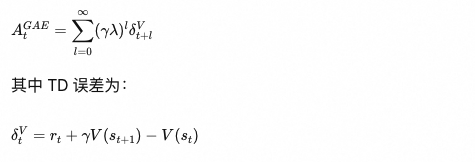

In [2]:
Image(filename='./Image/gae.png')

可以看到，奖励 $r_t$直接参与了优势函数的计算。而 <font color='red'>$V(s_t)$ 是 Critic 网络对“平均水平”的估计，它本身也是在不断拟合奖励分布。</font>

### 更直观的例子：batch 内的优势归一化
在 PPO 的实际实现中，通常还会对一个 batch 内的优势值做**标准化**：

$\hat{A}= \frac{A_t − mean(A)}{std(A) + ϵ}$

<font color='red'>这一步直接把优势值与当前 batch 奖励的均值和标准差绑定在一起。</font>

##  具体例子说明
### 例子 1：正常分布下的优势计算
假设一个 batch 有 5 个样本，奖励分别是 [1.0, 1.2, 0.9, 1.1, 1.0]：
  - 均值 ≈ 1.04，标准差 ≈ 0.1
  - 奖励 1.2 的样本：优势 ≈ +0.16（比平均好，鼓励）
  - 奖励 0.9 的样本：优势 ≈ -0.14（比平均差，抑制）
  - 结果：模型学会“多做能拿到 1.2 的动作，少做拿 0.9 的动作”，学习方向正确。
  
### 例子 2：奖励分布被离群点污染
假设奖励变成 [1.0, 1.2, 0.9, 1.1, **100.0**]（最后一个是 Bug 或极端运气）：
  - 均值被拉到 ≈ 20.84
  - <font color='red'>前 4 个正常样本的优势全部变成负数（因为 1.0 - 20.84 < 0）</font>
    - <font color='blue'>只有那个 100.0 的样本优势为正</font>
    - 结果：<font color='red'>模型会抑制所有正常行为，疯狂拟合那个异常样本，训练直接崩溃。</font>
  
这就是为什么说“优势函数的计算依赖于奖励分布”
    - <font color='red'>奖励分布的形态直接决定了哪些动作被鼓励、哪些被抑制。</font>
     - 如果分布本身有问题，优势函数就会给出错误的学习信号。

## 总结：依赖链条

In [ ]:
环境产生奖励 r_t
    ↓
奖励分布决定 V(s) 的估计（Critic 拟合目标）
    ↓
V(s) 作为基线，与 Q(s,a) 做差得到 A(s,a)
    ↓
A(s,a) 的正负和大小决定策略梯度方向
    ↓
策略梯度更新 π_θ，改变未来行为

<font color='red'>整条链条中，奖励分布是源头</font>
- 分布健康，优势函数就能正确区分好坏动作；
- 分布被污染（离群点、方差过大、均值漂移），优势函数就会给出错误信号，导致训练不稳定甚至崩溃。
- <font color='red'>这也是为什么在工程实践中需要对奖励做标准化、裁剪、离群点过滤等预处理的原因。</font>